# Chess Cheating Detection via TDA Mapper v3

This version uses a **4-class label** that distinguishes:
- `0` — both players clean
- `1` — white cheats only
- `2` — black cheats only
- `3` — both players cheat

The key TDA question: do 'both cheating' games form a topologically distinct
cluster from 'one player cheating' games, or do they all blend together?

**Assumes you have already run the Stockfish extraction and saved:**
`chess_features_extracted.csv`

If not, run v2 notebook first (Cells 1-7) to generate that file.

## Cell 1 — Imports

In [1]:
# Uncomment to install if needed:
# !pip install chess kmapper scikit-learn umap-learn pandas numpy matplotlib networkx

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

import kmapper as km
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from umap import UMAP

print('All imports successful.')

All imports successful.


## Cell 2 — Load extracted features

In [2]:
feat_df = pd.read_csv("chess_features_extracted.csv")
print(f"Loaded {len(feat_df)} games.")
print("Columns:", feat_df.columns.tolist())
feat_df.head(3)

Loaded 179 games.
Columns: ['mean_cpl', 'std_cpl', 'engine_agreement_rate', 'top3_agreement_rate', 'top1_streak_max', 'critical_move_accuracy', 'n_moves', 'elo_white', 'elo_black', 'cheat_white', 'cheat_black', 'either_cheat']


,mean_cpl,std_cpl,engine_agreement_rate,top3_agreement_rate,top1_streak_max,critical_move_accuracy,n_moves,elo_white,elo_black,cheat_white,cheat_black,either_cheat
0,7.092784,24.785298,0.612245,0.612245,9,NaN,97,1001,-1,1,1,1
1,318.298387,438.423201,0.552000,0.552000,6,NaN,124,1001,-1,1,1,1
2,373.144737,414.968696,0.558442,0.558442,6,NaN,76,1002,-1,1,1,1


## Cell 3 — Build 4-class cheat label

Rather than collapsing everything into either_cheat=0/1, we distinguish
the four distinct interaction types in this dataset.

In [19]:
def parse_cheat_label(val):
    """
    Handles: plain 0/1, string '0'/'1',
    long binary strings (majority vote), NaN.
    """
    if pd.isna(val):
        return 0
    s = str(val).strip()
    if s in ("0", "1"):
        return int(s)
    bits = [c for c in s if c in ("0", "1")]
    if bits:
        return int(sum(int(b) for b in bits) / len(bits) > 0.5)
    return 0


# Re-parse cheat labels cleanly in case CSV stored them as strings
feat_df["cheat_white"] = feat_df["cheat_white"].apply(parse_cheat_label)
feat_df["cheat_black"] = feat_df["cheat_black"].apply(parse_cheat_label)

def game_label(row):
    w, b = row["cheat_white"], row["cheat_black"]
    if   w == 0 and b == 0: return 0  # clean
    elif w == 1 and b == 0: return 1  # white cheats only
    elif w == 0 and b == 1: return 2  # black cheats only
    elif w == 1 and b == 1: return 3  # both cheat
    return -1

feat_df["game_label"]   = feat_df.apply(game_label, axis=1)
feat_df["either_cheat"] = (feat_df["game_label"] > 0).astype(int)

label_names  = {0: "Clean", 1: "White cheats", 2: "Black cheats", 3: "Both cheat"}
label_colors = {0: "steelblue", 1: "orange", 2: "tomato", 3: "darkred"}

counts = feat_df["game_label"].value_counts().sort_index()
print("Game label distribution:")
for k, v in counts.items():
    print(f"  {k} — {label_names[k]}: {v} games ({100*v/len(feat_df):.1f}%)")

    

Game label distribution:
  0 — Clean: 44 games (24.6%)
  1 — White cheats: 30 games (16.8%)
  2 — Black cheats: 59 games (33.0%)
  3 — Both cheat: 46 games (25.7%)


## Cell 4 — Label distribution plot

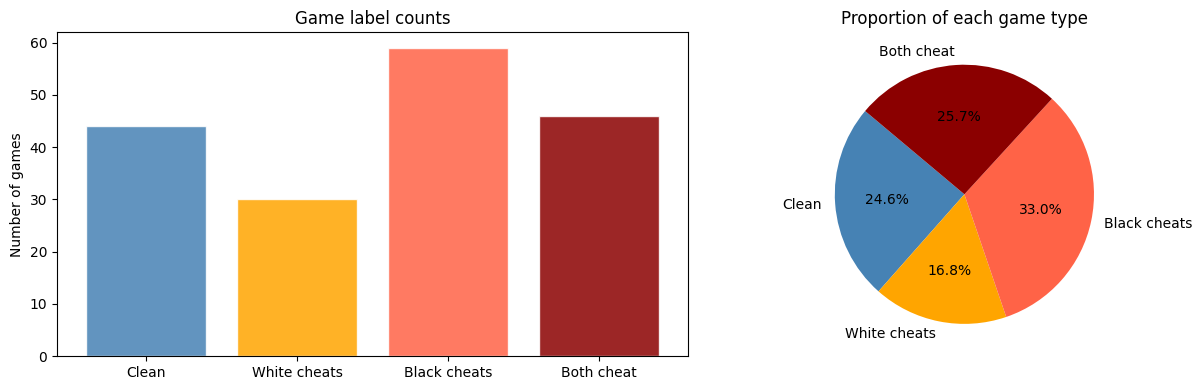

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart of label counts
labels_sorted = [0, 1, 2, 3]
counts_sorted = [counts.get(k, 0) for k in labels_sorted]
colors_sorted = [label_colors[k] for k in labels_sorted]
axes[0].bar([label_names[k] for k in labels_sorted], counts_sorted,
            color=colors_sorted, alpha=0.85, edgecolor='white')
axes[0].set_title("Game label counts")
axes[0].set_ylabel("Number of games")

# Pie chart
axes[1].pie(counts_sorted,
            labels=[label_names[k] for k in labels_sorted],
            colors=colors_sorted,
            autopct='%1.1f%%',
            startangle=140)
axes[1].set_title("Proportion of each game type")

plt.tight_layout()
plt.show()

## Cell 5 — Feature distributions by label

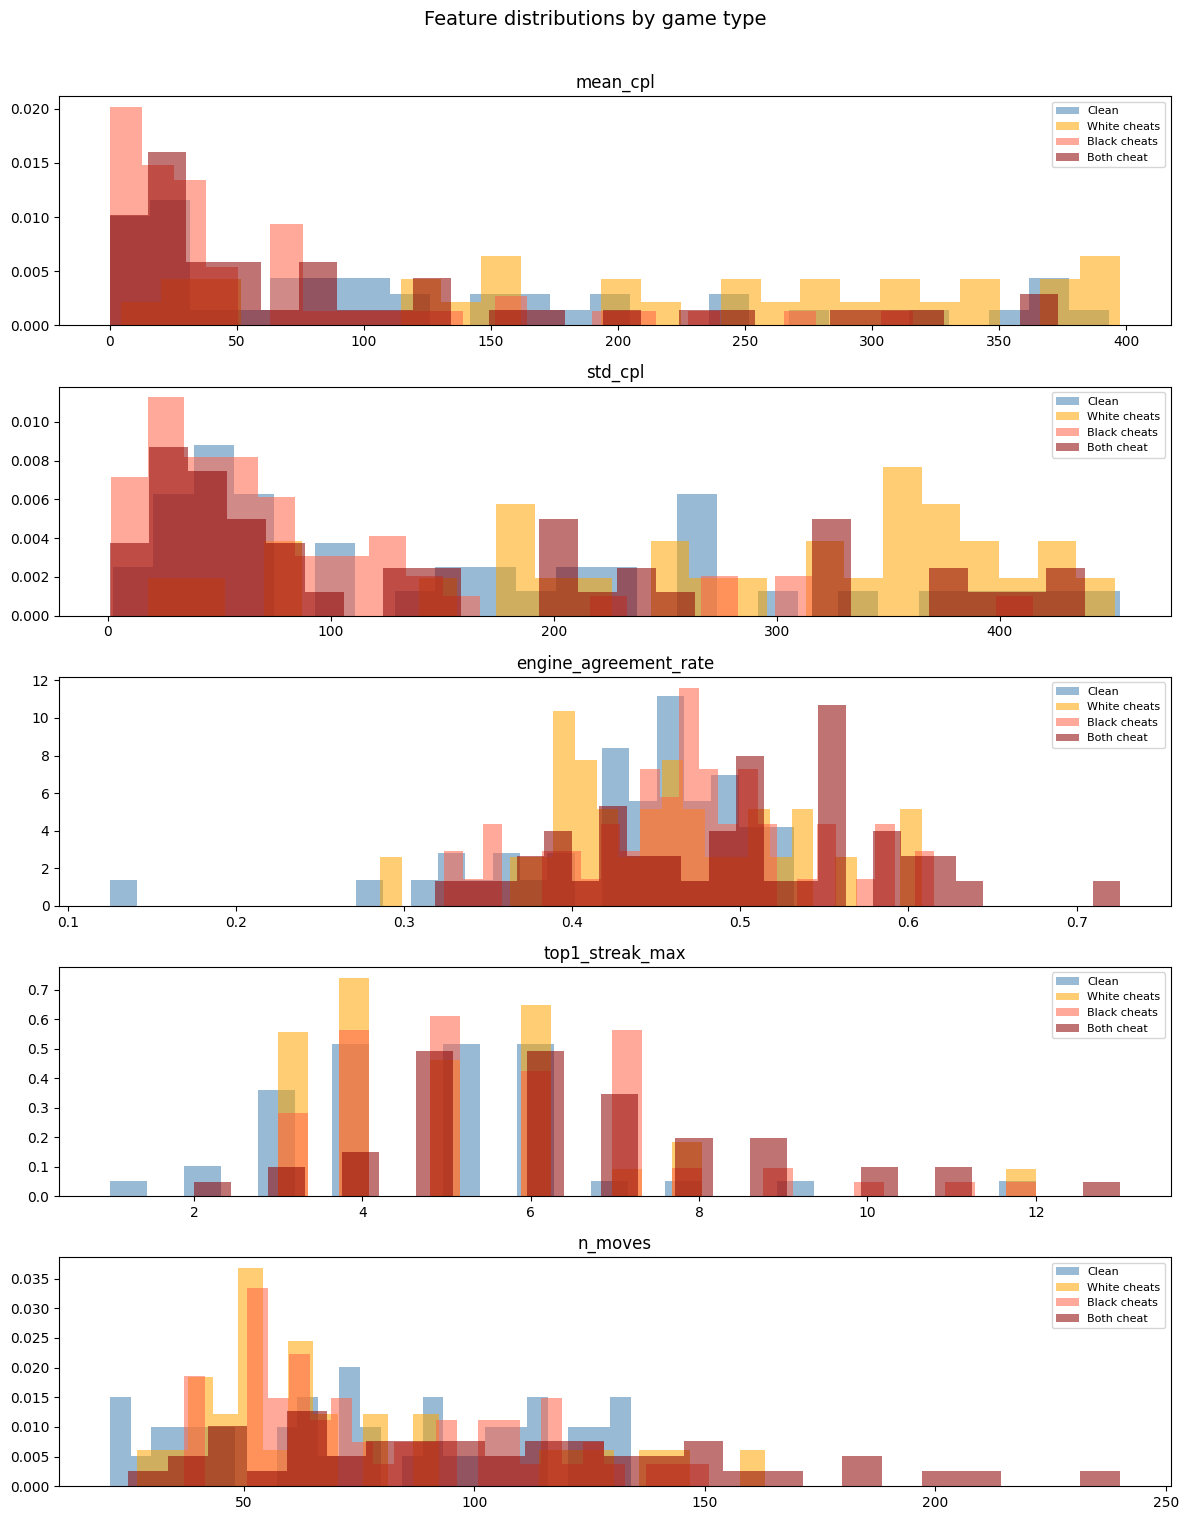


Mean feature values per game type:
              mean_cpl  std_cpl  engine_agreement_rate  top1_streak_max  \
game_label                                                                
Clean           124.14   159.60                   0.43             4.82   
White cheats    224.84   280.16                   0.46             5.07   
Black cheats     57.48    84.01                   0.47             5.69   
Both cheat       92.00   154.42                   0.50             6.57   

              n_moves  
game_label             
Clean           78.50  
White cheats    72.13  
Black cheats    80.98  
Both cheat     105.76  


In [21]:
feature_cols = ["mean_cpl", "std_cpl", "engine_agreement_rate",
                "top1_streak_max", "n_moves"]

fig, axes = plt.subplots(len(feature_cols), 1, figsize=(12, 3 * len(feature_cols)))

for ax, col in zip(axes, feature_cols):
    for label_id in [0, 1, 2, 3]:
        vals = feat_df[feat_df["game_label"] == label_id][col].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=25, alpha=0.55,
                    color=label_colors[label_id],
                    label=label_names[label_id],
                    density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle("Feature distributions by game type", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Mean feature values per label
print("\nMean feature values per game type:")
print(feat_df.groupby("game_label")[feature_cols].mean().round(2).rename(index=label_names))

## Cell 6 — Prepare feature matrix

In [22]:
feature_cols = ["mean_cpl", "std_cpl", "engine_agreement_rate",
                "top1_streak_max", "n_moves"]

# Elo is dropped entirely — too many -1 sentinels to be useful
# (-1 means original Elo was <1000 or >2000, not actually missing)

feat_df_clean = feat_df.dropna(subset=feature_cols).reset_index(drop=True)
print(f"Rows after cleaning: {len(feat_df_clean)}")

X_raw    = feat_df_clean[feature_cols].values
y_4class = feat_df_clean["game_label"].values.astype(int)
y_binary = feat_df_clean["either_cheat"].values.astype(int)

scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)

print(f"Feature matrix: {X.shape}")
print(f"Label distribution:")
for k in [0, 1, 2, 3]:
    n = (y_4class == k).sum()
    print(f"  {label_names[k]}: {n} ({100*n/len(y_4class):.1f}%)")

Rows after cleaning: 179
Feature matrix: (179, 5)
Label distribution:
  Clean: 44 (24.6%)
  White cheats: 30 (16.8%)
  Black cheats: 59 (33.0%)
  Both cheat: 46 (25.7%)


## Cell 7 — UMAP embedding (lens)

We first visualize the raw UMAP embedding colored by 4-class label
before applying Mapper, so we know what structure to expect.

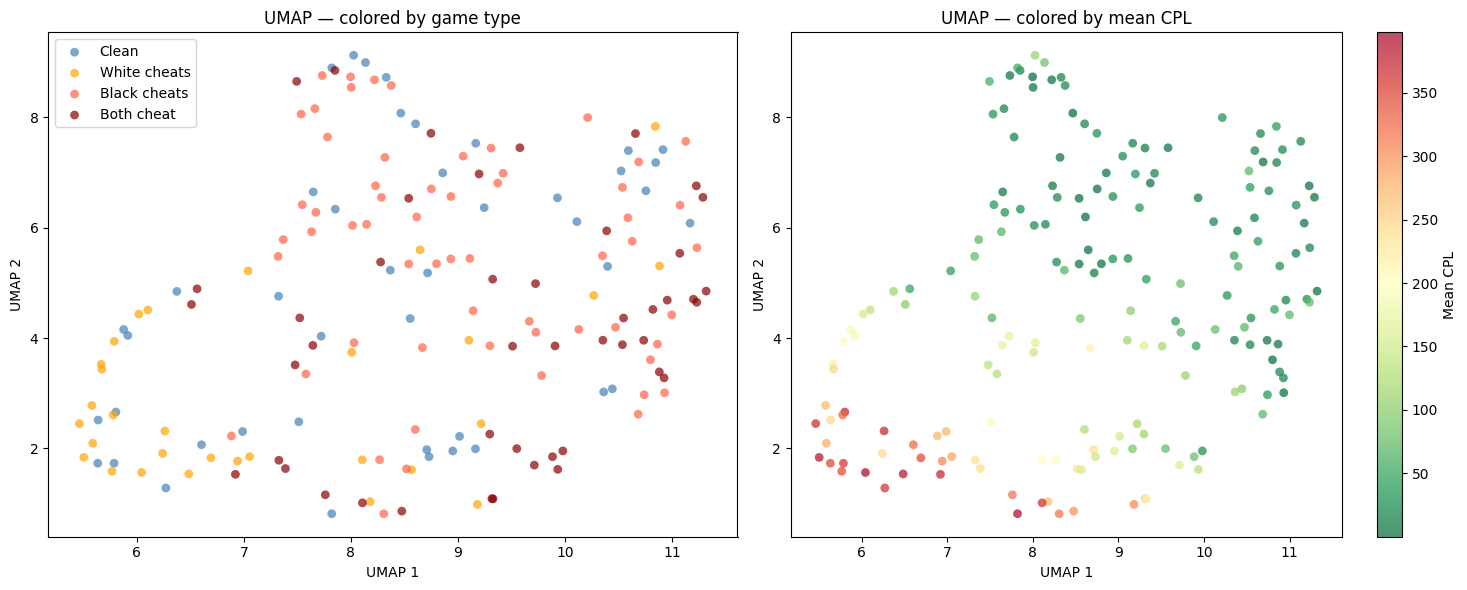

In [23]:
umap_model = UMAP(n_components=2, n_neighbors=12, min_dist=0.2, random_state=42)
lens       = umap_model.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: 4-class label
for label_id in [0, 1, 2, 3]:
    mask = y_4class == label_id
    axes[0].scatter(lens[mask, 0], lens[mask, 1],
                    c=label_colors[label_id],
                    label=label_names[label_id],
                    alpha=0.7, s=40, edgecolors='none')
axes[0].set_title("UMAP — colored by game type")
axes[0].legend()
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# Right: mean CPL as continuous color
cpl_vals = feat_df_clean["mean_cpl"].values
sc = axes[1].scatter(lens[:, 0], lens[:, 1],
                     c=cpl_vals, cmap='RdYlGn_r',
                     alpha=0.7, s=40, edgecolors='none')
plt.colorbar(sc, ax=axes[1], label='Mean CPL')
axes[1].set_title("UMAP — colored by mean CPL")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

## Cell 8 — Apply Mapper

Tuning guide:
- Too few nodes (<15): decrease `eps` or increase `n_cubes`
- Too many nodes (>60): increase `eps` or decrease `n_cubes`
- Graph too fragmented: increase `perc_overlap`
- Aim for 20-50 nodes for 179 data points

In [24]:
mapper = km.KeplerMapper(verbose=1)

graph = mapper.map(
    lens,
    X,
    clusterer=DBSCAN(eps=0.4, min_samples=2),
    cover=km.Cover(n_cubes=15, perc_overlap=0.5)
)

n_nodes = len(graph["nodes"])
n_edges = sum(len(v) for v in graph["links"].values())
print(f"\nMapper graph: {n_nodes} nodes, {n_edges} edges")

if n_nodes < 15:
    print("  Tip: too few nodes — try decreasing eps to 0.3 or increasing n_cubes to 20")
elif n_nodes > 60:
    print("  Tip: too many nodes — try increasing eps to 0.5 or decreasing n_cubes to 12")

KeplerMapper(verbose=1)
Mapping on data shaped (179, 5) using lens shaped (179, 2)

Creating 225 hypercubes.

Created 36 edges and 34 nodes in 0:00:00.215026.

Mapper graph: 34 nodes, 36 edges


## Cell 9 — Compute per-node statistics

In [25]:
node_stats = {}
for node, indices in graph["nodes"].items():
    labels_in_node = y_4class[indices]
    counts_in_node = np.bincount(labels_in_node, minlength=4)
    node_stats[node] = {
        "size":            len(indices),
        "indices":         indices,
        "label_counts":    counts_in_node,
        "majority_label":  int(np.argmax(counts_in_node)),
        "cheat_rate":      float(np.mean(y_binary[indices])),
        "mean_cpl":        float(np.mean(feat_df_clean["mean_cpl"].values[indices])),
        "mean_agreement":  float(np.mean(feat_df_clean["engine_agreement_rate"].values[indices])),
        # Fraction of each class within the node
        "frac_clean":      counts_in_node[0] / len(indices),
        "frac_white":      counts_in_node[1] / len(indices),
        "frac_black":      counts_in_node[2] / len(indices),
        "frac_both":       counts_in_node[3] / len(indices),
    }

# Build networkx graph
G = nx.Graph()
for node in graph["nodes"]:
    G.add_node(node)
for node, neighbors in graph["links"].items():
    for nb in neighbors:
        G.add_edge(node, nb)

print(f"NetworkX graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected components: {nx.number_connected_components(G)}")

NetworkX graph: 34 nodes, 36 edges
Connected components: 13


## Cell 10 — Main visualization: 4-class Mapper graph

Four subplots, each coloring nodes by a different signal:
1. Majority label (4-class)
2. Fraction of 'both cheat' games per node
3. Mean CPL per node
4. Mean engine agreement rate per node

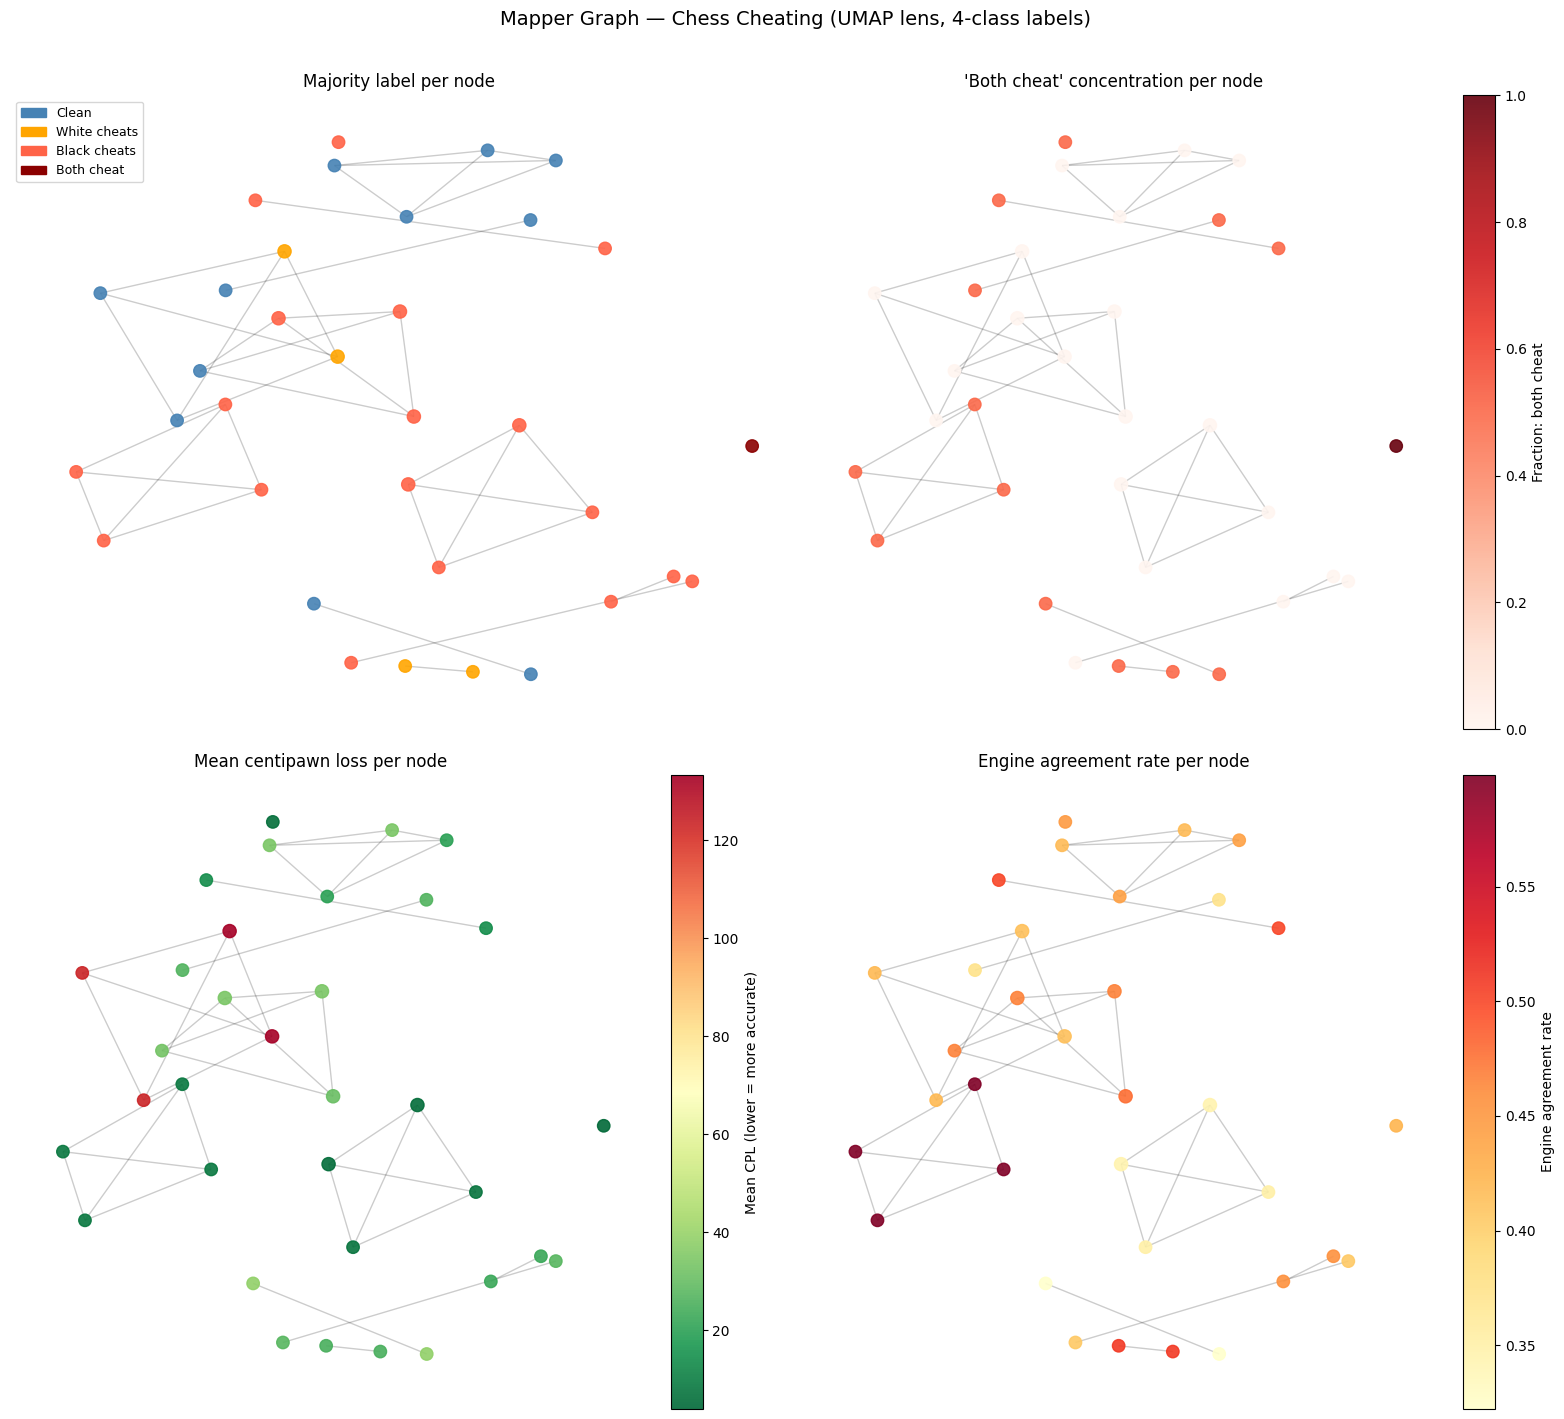

In [26]:
pos       = nx.spring_layout(G, seed=42, k=1.0)
node_list = list(G.nodes())
sizes     = [max(80, node_stats[n]["size"] * 30) for n in node_list]
degrees   = dict(G.degree())

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes      = axes.flatten()

# ── Plot 1: Majority label (4-class) ─────────────────────────
ax = axes[0]
node_colors_4class = [label_colors[node_stats[n]["majority_label"]] for n in node_list]
nx.draw_networkx_nodes(G, pos, node_color=node_colors_4class,
                       node_size=sizes, ax=ax, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
legend_patches = [mpatches.Patch(color=label_colors[k], label=label_names[k])
                  for k in [0, 1, 2, 3]]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
ax.set_title("Majority label per node", fontsize=12)
ax.axis("off")

# ── Plot 2: Fraction of 'both cheat' per node ────────────────
ax = axes[1]
both_fracs = [node_stats[n]["frac_both"] for n in node_list]
drawn = nx.draw_networkx_nodes(G, pos, node_color=both_fracs,
                               node_size=sizes, cmap=plt.cm.Reds,
                               vmin=0, vmax=1, ax=ax, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
plt.colorbar(drawn, ax=ax, label='Fraction: both cheat')
ax.set_title("'Both cheat' concentration per node", fontsize=12)
ax.axis("off")

# ── Plot 3: Mean CPL per node ─────────────────────────────────
ax = axes[2]
cpl_vals_node = [node_stats[n]["mean_cpl"] for n in node_list]
drawn = nx.draw_networkx_nodes(G, pos, node_color=cpl_vals_node,
                               node_size=sizes, cmap=plt.cm.RdYlGn_r,
                               ax=ax, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
plt.colorbar(drawn, ax=ax, label='Mean CPL (lower = more accurate)')
ax.set_title("Mean centipawn loss per node", fontsize=12)
ax.axis("off")

# ── Plot 4: Engine agreement rate ────────────────────────────
ax = axes[3]
agree_vals = [node_stats[n]["mean_agreement"] for n in node_list]
drawn = nx.draw_networkx_nodes(G, pos, node_color=agree_vals,
                               node_size=sizes, cmap=plt.cm.YlOrRd,
                               ax=ax, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
plt.colorbar(drawn, ax=ax, label='Engine agreement rate')
ax.set_title("Engine agreement rate per node", fontsize=12)
ax.axis("off")

plt.suptitle("Mapper Graph — Chess Cheating (UMAP lens, 4-class labels)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Cell 11 — Interactive HTML (open in browser for hover details)

In [27]:
# Color by 4-class majority label for the HTML viz
html_path = "chess_cheating_mapper_v3.html"
mapper.visualize(
    graph,
    path_html=html_path,
    color_values=y_4class,
    color_function_name="Game type (0=clean, 1=white, 2=black, 3=both)",
    title="Chess Cheating — 4-class Mapper (UMAP lens)"
)
print(f"Saved: {html_path}")

Wrote visualization to: chess_cheating_mapper_v3.html
Saved: chess_cheating_mapper_v3.html


## Cell 12 — Topological structure analysis

In [28]:
print("=" * 60)
print("CONNECTED COMPONENTS")
print("=" * 60)
components = list(nx.connected_components(G))
for i, comp in enumerate(sorted(components, key=len, reverse=True)):
    all_indices = []
    for n in comp:
        all_indices.extend(node_stats[n]["indices"])
    all_indices  = list(set(all_indices))
    comp_labels  = y_4class[all_indices]
    comp_counts  = np.bincount(comp_labels, minlength=4)
    total        = len(all_indices)
    print(f"\nComponent {i+1}: {len(comp)} nodes, {total} games")
    for k in [0, 1, 2, 3]:
        print(f"  {label_names[k]}: {comp_counts[k]} ({100*comp_counts[k]/total:.1f}%)")

print()
print("=" * 60)
print("CYCLES (H1 topological features)")
print("=" * 60)
cycles = nx.cycle_basis(G)
print(f"Total cycles detected: {len(cycles)}")
for i, cycle in enumerate(cycles[:8]):
    all_indices = []
    for n in cycle:
        all_indices.extend(node_stats[n]["indices"])
    all_indices = list(set(all_indices))
    cycle_labels = y_4class[all_indices]
    cycle_counts = np.bincount(cycle_labels, minlength=4)
    dominant = label_names[np.argmax(cycle_counts)]
    print(f"  Cycle {i+1}: length={len(cycle)}, dominant={dominant}, "
          f"clean={cycle_counts[0]}, white={cycle_counts[1]}, "
          f"black={cycle_counts[2]}, both={cycle_counts[3]}")

print()
print("=" * 60)
print("ISOLATED NODES (topologically separate populations)")
print("=" * 60)
isolated = [n for n in G.nodes() if degrees[n] == 0]
degree_1  = [n for n in G.nodes() if degrees[n] == 1]
print(f"Fully isolated (degree=0): {len(isolated)}")
for n in isolated:
    s = node_stats[n]
    print(f"  {n}: size={s['size']}, majority={label_names[s['majority_label']]}, "
          f"CPL={s['mean_cpl']:.1f}, agreement={s['mean_agreement']:.3f}")
print(f"Near-isolated (degree=1): {len(degree_1)}")
for n in degree_1:
    s = node_stats[n]
    print(f"  {n}: size={s['size']}, majority={label_names[s['majority_label']]}, "
          f"CPL={s['mean_cpl']:.1f}, agreement={s['mean_agreement']:.3f}")

CONNECTED COMPONENTS

Component 1: 4 nodes, 3 games
  Clean: 1 (33.3%)
  White cheats: 2 (66.7%)
  Black cheats: 0 (0.0%)
  Both cheat: 0 (0.0%)

Component 2: 4 nodes, 4 games
  Clean: 1 (25.0%)
  White cheats: 0 (0.0%)
  Black cheats: 3 (75.0%)
  Both cheat: 0 (0.0%)

Component 3: 4 nodes, 3 games
  Clean: 0 (0.0%)
  White cheats: 0 (0.0%)
  Black cheats: 3 (100.0%)
  Both cheat: 0 (0.0%)

Component 4: 4 nodes, 2 games
  Clean: 0 (0.0%)
  White cheats: 0 (0.0%)
  Black cheats: 1 (50.0%)
  Both cheat: 1 (50.0%)

Component 5: 4 nodes, 3 games
  Clean: 2 (66.7%)
  White cheats: 1 (33.3%)
  Black cheats: 0 (0.0%)
  Both cheat: 0 (0.0%)

Component 6: 2 nodes, 2 games
  Clean: 0 (0.0%)
  White cheats: 0 (0.0%)
  Black cheats: 2 (100.0%)
  Both cheat: 0 (0.0%)

Component 7: 2 nodes, 2 games
  Clean: 1 (50.0%)
  White cheats: 0 (0.0%)
  Black cheats: 0 (0.0%)
  Both cheat: 1 (50.0%)

Component 8: 2 nodes, 2 games
  Clean: 0 (0.0%)
  White cheats: 0 (0.0%)
  Black cheats: 2 (100.0%)
  Both che

## Cell 13 — Feature profiles: all 4 game types compared

Boxplots comparing feature distributions across all four label types.

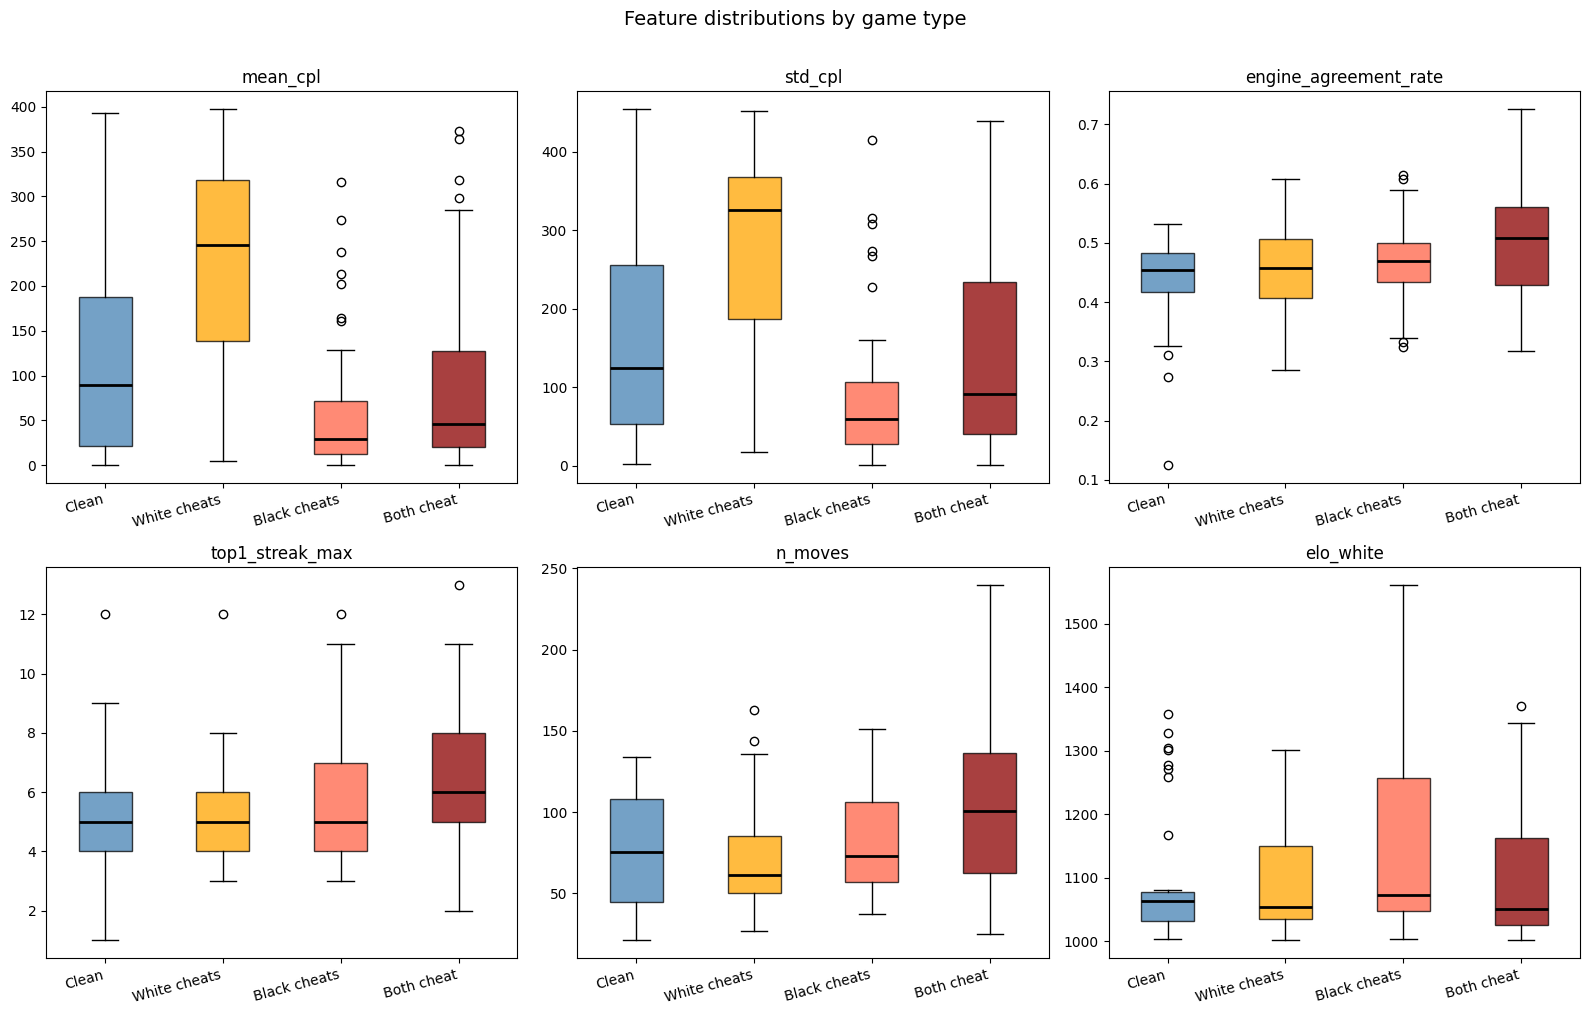


Mean feature values per game type:
              mean_cpl  std_cpl  engine_agreement_rate  top1_streak_max  n_moves  elo_white
Clean          124.137  159.599                  0.433            4.818   78.500   1089.864
White cheats   224.838  280.163                  0.457            5.067   72.133   1097.500
Black cheats    57.481   84.015                  0.470            5.695   80.983   1134.288
Both cheat      91.998  154.416                  0.497            6.565  105.761   1106.761


In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_features = ["mean_cpl", "std_cpl", "engine_agreement_rate",
                 "top1_streak_max", "n_moves", "elo_white"]

for ax, col in zip(axes, plot_features):
    data_by_label = [
        feat_df_clean[feat_df_clean["game_label"] == k][col].dropna().values
        for k in [0, 1, 2, 3]
    ]
    bp = ax.boxplot(data_by_label,
                    patch_artist=True,
                    medianprops={"color": "black", "linewidth": 2})
    for patch, k in zip(bp['boxes'], [0, 1, 2, 3]):
        patch.set_facecolor(label_colors[k])
        patch.set_alpha(0.75)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels([label_names[k] for k in [0,1,2,3]], rotation=15, ha='right')
    ax.set_title(col)

plt.suptitle("Feature distributions by game type", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
print("\nMean feature values per game type:")
summary = feat_df_clean.groupby("game_label")[plot_features].mean().round(3)
summary.index = [label_names[k] for k in summary.index]
print(summary.to_string())

## Cell 14 — Does 'both cheat' separate from 'one cheats'?

The core research question: are games where both players cheat
topologically distinct from games where only one player cheats?

In [30]:
# Collect node indices by dominant game type
nodes_by_type = {k: [] for k in [0, 1, 2, 3]}
for node, s in node_stats.items():
    nodes_by_type[s["majority_label"]].append(node)

print("Nodes dominated by each game type:")
for k in [0, 1, 2, 3]:
    print(f"  {label_names[k]}: {len(nodes_by_type[k])} nodes")

print()

# Are 'both cheat' nodes adjacent to 'clean' nodes?
both_nodes  = set(nodes_by_type[3])
clean_nodes = set(nodes_by_type[0])

both_to_clean_edges = [
    (u, v) for u, v in G.edges()
    if (u in both_nodes and v in clean_nodes) or
       (v in both_nodes and u in clean_nodes)
]
both_to_single_edges = [
    (u, v) for u, v in G.edges()
    if (u in both_nodes and v in (nodes_by_type[1] + nodes_by_type[2])) or
       (v in both_nodes and u in (nodes_by_type[1] + nodes_by_type[2]))
]

print(f"Edges between 'both cheat' and 'clean' nodes: {len(both_to_clean_edges)}")
print(f"Edges between 'both cheat' and 'one cheats' nodes: {len(both_to_single_edges)}")

if len(both_to_clean_edges) == 0:
    print("\n -> 'Both cheat' nodes are NOT directly connected to clean nodes.")
    print("    This suggests they occupy a topologically distinct region.")
else:
    print("\n -> 'Both cheat' nodes share edges with clean nodes.")
    print("    The boundary between cheating types is not sharp in this dataset.")

# Shortest path between a 'both cheat' node and a 'clean' node
if both_nodes and clean_nodes:
    try:
        sample_both  = list(both_nodes)[0]
        sample_clean = list(clean_nodes)[0]
        path = nx.shortest_path(G, sample_both, sample_clean)
        path_labels = [label_names[node_stats[n]["majority_label"]] for n in path]
        print(f"\nShortest path from a 'both cheat' node to a 'clean' node:")
        print(f"  Length: {len(path)-1} hops")
        print(f"  Label sequence: {' -> '.join(path_labels)}")
    except nx.NetworkXNoPath:
        print("\nNo path exists between 'both cheat' and 'clean' nodes.")
        print("They are in completely separate connected components — strong separation signal.")
    except nx.NodeNotFound:
        print("\nCould not find path (nodes may be in different components).")

Nodes dominated by each game type:
  Clean: 11 nodes
  White cheats: 4 nodes
  Black cheats: 18 nodes
  Both cheat: 1 nodes

Edges between 'both cheat' and 'clean' nodes: 0
Edges between 'both cheat' and 'one cheats' nodes: 0

 -> 'Both cheat' nodes are NOT directly connected to clean nodes.
    This suggests they occupy a topologically distinct region.

No path exists between 'both cheat' and 'clean' nodes.
They are in completely separate connected components — strong separation signal.


## Cell 15 — Interpretation summary

Run this last to get a plain-English summary of your findings.

In [31]:
n_components = nx.number_connected_components(G)
n_cycles     = len(nx.cycle_basis(G))
n_nodes      = G.number_of_nodes()
n_edges      = G.number_of_edges()

print("=" * 60)
print("TOPOLOGICAL SUMMARY")
print("=" * 60)
print(f"  Nodes: {n_nodes}  |  Edges: {n_edges}")
print(f"  Connected components: {n_components}")
print(f"  Cycles (H1 features): {n_cycles}")
print()

# Component composition
for i, comp in enumerate(sorted(nx.connected_components(G), key=len, reverse=True)[:4]):
    all_idx    = list(set(idx for n in comp for idx in node_stats[n]["indices"]))
    comp_labs  = y_4class[all_idx]
    comp_cnt   = np.bincount(comp_labs, minlength=4)
    dominant   = label_names[np.argmax(comp_cnt)]
    print(f"  Component {i+1} ({len(comp)} nodes, {len(all_idx)} games): "
          f"dominant = {dominant}")

print()
print("=" * 60)
print("WHAT TO LOOK FOR")
print("=" * 60)
print("""
  If 'both cheat' games form a separate component from 'clean' games:
  -> The behavioral geometry of mutual cheating is fundamentally
     different, not just an extreme of normal play.

  If 'white cheats' and 'black cheats' nodes cluster together:
  -> The side doing the cheating doesn't matter much for detection;
     cheating leaves the same behavioral fingerprint regardless.

  If cycles appear within the cheating population:
  -> Multiple cheating strategies exist that produce similar
     outcomes via different behavioral paths.

  If clean games appear isolated at low-CPL, high-agreement nodes:
  -> Paradox: clean high-rated players and cheaters look similar
     on raw accuracy — Elo-adjusted features would help here.
""")

TOPOLOGICAL SUMMARY
  Nodes: 34  |  Edges: 36
  Connected components: 13
  Cycles (H1 features): 15

  Component 1 (4 nodes, 3 games): dominant = White cheats
  Component 2 (4 nodes, 4 games): dominant = Black cheats
  Component 3 (4 nodes, 3 games): dominant = Black cheats
  Component 4 (4 nodes, 2 games): dominant = Black cheats

WHAT TO LOOK FOR

  If 'both cheat' games form a separate component from 'clean' games:
  -> The behavioral geometry of mutual cheating is fundamentally
     different, not just an extreme of normal play.

  If 'white cheats' and 'black cheats' nodes cluster together:
  -> The side doing the cheating doesn't matter much for detection;
     cheating leaves the same behavioral fingerprint regardless.

  If cycles appear within the cheating population:
  -> Multiple cheating strategies exist that produce similar
     outcomes via different behavioral paths.

  If clean games appear isolated at low-CPL, high-agreement nodes:
  -> Paradox: clean high-rated player